In [29]:
# Step 0 — Environment: load `.env` so GEMINI_API_KEY and related settings are available.
import os
from dotenv import load_dotenv

load_dotenv()


True

In [30]:
# Step 0 — Configure Gemini keys, chat model caps, and embedding rate limits (same pattern as text RAG notebook).
import os

_gem = os.getenv("GEMINI_API_KEY")
if _gem:
    os.environ["GEMINI_API_KEY"] = _gem
    os.environ["GOOGLE_API_KEY"] = _gem

os.environ.setdefault("GEMINI_MODEL", "gemini-2.5-flash-lite")
os.environ.setdefault("GEMINI_MAX_OUTPUT_TOKENS", "256")

# Embedding free tier: cap items and pause between API calls.
os.environ.setdefault("GEMINI_EMBED_MAX_CHUNKS", "12")
os.environ.setdefault("GEMINI_EMBED_API_PAUSE_SEC", "1.05")
os.environ.setdefault("GEMINI_EMBED_ON_429_WAIT", "48")
# Multimodal index model (see resolve_multimodal_embed_model in Step 4 cell).
os.environ.setdefault("MULTIMODAL_DATA_DIR", "data/multimodal")


'data/multimodal'

In [31]:
# Step 0 — Build the Gemini chat model (used in Step 7 generation; supports text + image inputs).
from langchain_google_genai import ChatGoogleGenerativeAI

_model = os.environ.get("GEMINI_MODEL", "gemini-2.5-flash-lite")
_max_out = int(os.environ.get("GEMINI_MAX_OUTPUT_TOKENS", "256"))
llm = ChatGoogleGenerativeAI(model=_model, max_output_tokens=_max_out)
print(llm)


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


output_version=None profile={'name': 'Gemini 2.5 Flash Lite', 'release_date': '2025-06-17', 'last_updated': '2025-06-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True} google_api_key=SecretStr('**********') location=None model='gemini-2.5-flash-lite' max_output_tokens=256 client=<google.genai.client.Client object at 0x000002147FD52A50> default_metadata=() model_kwargs={}


In [32]:
# Step 0 — Smoke-test the LLM (text-only).
result = llm.invoke("Define multimodal RAG in one sentence.")
print(result.content)


Multimodal RAG (Retrieval Augmented Generation) enhances traditional RAG by allowing the retrieval and integration of information from multiple data modalities (like text, images, and audio) to generate more comprehensive and contextually relevant responses.


# Multimodal RAG pipeline

This notebook mirrors `rag-pipeline.ipynb`, but indexes **images + captions** instead of HTML text only.

### Workflow (steps)

| Step | Name | What happens |
|------|------|----------------|
| **1** | **Load** | Scan `data/multimodal/` for your image files and build `Document` objects (`page_content` = caption, metadata holds `image_path`). |
| **2** | **Chunking** | Split long captions into smaller segments (`chunk_size`). |
| **3** | **Overlapping** | Duplicate characters at chunk boundaries (`chunk_overlap`) so meaning is not cut in half. |
| **4** | **Embed** | Encode **caption + image bytes** into one vector with Gemini (`google-genai` SDK). |
| **5** | **Index** | Store vectors in **FAISS** for fast similarity search. |
| **6** | **Retrieve** | Embed the user question (text) and fetch the nearest image+caption records. |
| **7** | **Generate** | Send retrieved **images + captions** to the vision-capable Gemini model and produce an answer. |

> **Note:** `models/gemini-embedding-001` is **text-only** (image parts are dropped → empty-text error). Step 4 uses `gemini-embedding-2-preview` for image+caption vectors, with automatic caption-only fallback.


In [33]:
# Step 1 (Load) — imports for building local sample images and documents.
import mimetypes
import time
from pathlib import Path

from langchain_core.documents import Document


In [34]:
# Step 1 (Load) — put your images in DATA_DIR; optional captions below (re-run after adding files).
DATA_DIR = Path(os.environ.get("MULTIMODAL_DATA_DIR", "data/multimodal"))
DATA_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".webp", ".gif"}

# Manual captions (exact filename). Leave empty {} to rely on vision auto-caption only.
IMAGE_CAPTIONS: dict[str, str] = {}

# If True, Gemini writes a caption from each image (better retrieval than filename guesses).
AUTO_CAPTION_WITH_VISION = os.getenv("AUTO_CAPTION_WITH_VISION", "true").lower() in (
    "1",
    "true",
    "yes",
)

print("Image folder:", DATA_DIR.resolve())
found = sorted(p.name for p in DATA_DIR.iterdir() if p.suffix.lower() in IMAGE_SUFFIXES)
print(f"Found {len(found)} image(s):", found)


Image folder: C:\Users\TEAMAPEX-003\Downloads\rag_practice\data\multimodal
Found 6 image(s): ['Auto rides.jpg', 'cat.jpg', 'cats.jpg', 'domino.jpg', 'iphone.jpg', 'sunflower.jpg']


In [35]:
# Step 1 (Load) — scan DATA_DIR and build one Document per image file.
import base64

from langchain_core.messages import HumanMessage


def caption_from_filename(filename: str) -> str:
    stem = Path(filename).stem.replace("_", " ").replace("-", " ")
    return f"Photo related to {stem}."


def caption_image_with_vision(image_path: Path) -> str:
    """Ask Gemini to describe the image (used for embedding / retrieval)."""
    mime, _ = mimetypes.guess_type(image_path)
    mime = mime or "image/jpeg"
    b64 = base64.standard_b64encode(image_path.read_bytes()).decode()
    msg = HumanMessage(
        content=[
            {
                "type": "text",
                "text": (
                    "Describe this image in one detailed sentence for a search index. "
                    "Name the main subject(s), colors, and setting. Do not mention dogs unless you see a dog."
                ),
            },
            {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{b64}"}},
        ]
    )
    return llm.invoke([msg]).content.strip()


def load_images_from_dir(data_dir: Path) -> list[Document]:
    image_files = sorted(
        p for p in data_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES
    )
    if not image_files:
        raise FileNotFoundError(
            f"No images in {data_dir.resolve()}. Add .jpg/.png files and re-run."
        )
    documents: list[Document] = []
    for path in image_files:
        if path.name in IMAGE_CAPTIONS:
            caption = IMAGE_CAPTIONS[path.name]
        elif AUTO_CAPTION_WITH_VISION:
            print("Vision caption:", path.name, "...")
            caption = caption_image_with_vision(path)
        else:
            caption = caption_from_filename(path.name)
        documents.append(
            Document(
                page_content=caption,
                metadata={
                    "image_path": str(path.resolve()),
                    "source": f"local:{path.stem}",
                    "filename": path.name,
                },
            )
        )
    return documents


raw_documents = load_images_from_dir(DATA_DIR)
print(f"Loaded {len(raw_documents)} image documents from {DATA_DIR}")
for d in raw_documents:
    print("-", d.metadata["filename"], "|", d.page_content)


Loaded 6 image documents from data\multimodal
- Auto rides.jpg | An automobile or ride-related scene.
- cat.jpg | A domestic cat portrait.
- cats.jpg | A photo with one or more cats.
- domino.jpg | Domino tiles or a domino game.
- iphone.jpg | An Apple iPhone smartphone.
- sunflower.jpg | A bright yellow sunflower.


In [36]:
# Steps 2–3 (Chunking + Overlapping) — split long captions; overlap keeps context across chunk borders.
from langchain_text_splitters import RecursiveCharacterTextSplitter

_max = int(os.environ.get("GEMINI_EMBED_MAX_CHUNKS", "12"))
# Step 2 — chunk_size limits characters per caption segment.
# Step 3 — chunk_overlap reuses tail/head characters between neighbors.
text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=40)
documents = text_splitter.split_documents(raw_documents)
documents = documents[:_max]
print(f"Indexing {len(documents)} multimodal chunks (GEMINI_EMBED_MAX_CHUNKS={_max})")
documents


Indexing 6 multimodal chunks (GEMINI_EMBED_MAX_CHUNKS=12)


[Document(metadata={'image_path': 'C:\\Users\\TEAMAPEX-003\\Downloads\\rag_practice\\data\\multimodal\\Auto rides.jpg', 'source': 'local:Auto rides', 'filename': 'Auto rides.jpg'}, page_content='An automobile or ride-related scene.'),
 Document(metadata={'image_path': 'C:\\Users\\TEAMAPEX-003\\Downloads\\rag_practice\\data\\multimodal\\cat.jpg', 'source': 'local:cat', 'filename': 'cat.jpg'}, page_content='A domestic cat portrait.'),
 Document(metadata={'image_path': 'C:\\Users\\TEAMAPEX-003\\Downloads\\rag_practice\\data\\multimodal\\cats.jpg', 'source': 'local:cats', 'filename': 'cats.jpg'}, page_content='A photo with one or more cats.'),
 Document(metadata={'image_path': 'C:\\Users\\TEAMAPEX-003\\Downloads\\rag_practice\\data\\multimodal\\domino.jpg', 'source': 'local:domino', 'filename': 'domino.jpg'}, page_content='Domino tiles or a domino game.'),
 Document(metadata={'image_path': 'C:\\Users\\TEAMAPEX-003\\Downloads\\rag_practice\\data\\multimodal\\iphone.jpg', 'source': 'local:ip

In [40]:
# Step 4 (Embed) — custom multimodal embedder: fuse caption text + image bytes via Google GenAI SDK.
import os
import time
from pathlib import Path

from google import genai
from google.genai import types
from langchain_core.embeddings import Embeddings


def resolve_multimodal_embed_model() -> str:
    """Pick embed model for this notebook (.env often sets text-only embedding-001)."""
    force_001 = os.getenv("FORCE_GEMINI_EMBEDDING_001", "").strip().lower() in (
        "1",
        "true",
        "yes",
    )
    if force_001:
        model = (
            os.getenv("GEMINI_MULTIMODAL_EMBEDDING_MODEL")
            or os.getenv("GEMINI_EMBEDDING_MODEL")
            or "models/gemini-embedding-001"
        )
    else:
        # This notebook needs embedding-2 for image+text vectors.
        model = "models/gemini-embedding-2-preview"
    os.environ["GEMINI_MULTIMODAL_EMBEDDING_MODEL"] = model
    return model


class MultimodalGeminiEmbeddings(Embeddings):
    """Embed caption + image (embedding-2) or caption-only fallback (embedding-001)."""

    def __init__(self, model: str | None = None):
        api_key = os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY")
        self.client = genai.Client(api_key=api_key)
        self.model = model or resolve_multimodal_embed_model()
        self.pause = float(os.environ.get("GEMINI_EMBED_API_PAUSE_SEC", "1.05"))
        self.on_429 = float(os.environ.get("GEMINI_EMBED_ON_429_WAIT", "48"))

    def _supports_image_embedding(self) -> bool:
        return "embedding-2" in self.model.lower()

    def _embed_parts(self, parts: list, *, task_type: str) -> list[float]:
        for attempt in range(3):
            try:
                response = self.client.models.embed_content(
                    model=self.model,
                    contents=parts,
                    config=types.EmbedContentConfig(task_type=task_type),
                )
                if not response.embeddings:
                    raise ValueError("No embeddings returned from Gemini")
                return list(response.embeddings[0].values)
            except Exception as err:
                msg = str(err)
                if attempt < 2 and ("429" in msg or "RESOURCE_EXHAUSTED" in msg):
                    time.sleep(self.on_429)
                    continue
                raise

    def _text_part(self, doc: Document) -> types.Part:
        text = (doc.page_content or "").strip()
        if not text:
            text = str(doc.metadata.get("filename", "image"))
        return types.Part.from_text(text=text)

    def embed_document(self, doc: Document) -> list[float]:
        text_part = self._text_part(doc)
        image_path = doc.metadata.get("image_path")

        if self._supports_image_embedding() and image_path and Path(image_path).is_file():
            mime, _ = mimetypes.guess_type(image_path)
            mime = mime or "image/jpeg"
            parts = [
                text_part,
                types.Part.from_bytes(
                    data=Path(image_path).read_bytes(), mime_type=mime
                ),
            ]
            try:
                return self._embed_parts(parts, task_type="RETRIEVAL_DOCUMENT")
            except Exception as err:
                # If multimodal is rejected, fall back to caption-only embedding.
                if "empty" not in str(err).lower() and "INVALID_ARGUMENT" not in str(err):
                    raise

        return self._embed_parts([text_part], task_type="RETRIEVAL_DOCUMENT")

    def embed_query(self, text: str) -> list[float]:
        query = (text or "").strip() or "query"
        return self._embed_parts(
            [types.Part.from_text(text=query)], task_type="RETRIEVAL_QUERY"
        )

    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        raise NotImplementedError("Use embed_document() per Document for multimodal indexing.")


embeddings = MultimodalGeminiEmbeddings()
print("Multimodal embed model:", embeddings.model)
print("Image+text embedding:", embeddings._supports_image_embedding())
print("(.env GEMINI_EMBEDDING_MODEL =", os.getenv("GEMINI_EMBEDDING_MODEL"), ")")
print("(.env GEMINI_MULTIMODAL_EMBEDDING_MODEL =", os.getenv("GEMINI_MULTIMODAL_EMBEDDING_MODEL"), ")")


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Multimodal embed model: models/gemini-embedding-2-preview
Image+text embedding: True
(.env GEMINI_EMBEDDING_MODEL = None )
(.env GEMINI_MULTIMODAL_EMBEDDING_MODEL = models/gemini-embedding-2-preview )


In [41]:
# Step 5 (Index) — build FAISS from (vector, Document) pairs (one embed call per chunk).
from langchain_community.vectorstores import FAISS

# FAISS.from_embeddings expects (text, vector) pairs — not (vector, Document).
text_embedding_pairs: list[tuple[str, list[float]]] = []
metadatas: list[dict] = []
for i, doc in enumerate(documents):
    vec = embeddings.embed_document(doc)
    text_embedding_pairs.append((doc.page_content, vec))
    metadatas.append(doc.metadata)
    if i + 1 < len(documents) and embeddings.pause > 0:
        time.sleep(embeddings.pause)

vectorstore = FAISS.from_embeddings(
    text_embedding_pairs, embeddings, metadatas=metadatas
)
vectorstore


In [45]:
# Step 6 (Retrieve) — similarity search (only returns images you indexed in data/multimodal/).
# Your folder has cats, iphone, sunflower, domino, auto — no dog.jpg, so a "dog" query cannot retrieve a dog.
query = "yellow sunflower flower"
retrieved = vectorstore.similarity_search_with_score(query, k=3)
print("Query:", query, "\n")
for rank, (doc, score) in enumerate(retrieved, start=1):
    print(f"[{rank}] score={score:.4f} | {doc.metadata.get('filename')}")
    print(f"    caption: {doc.page_content}\n")


Query: yellow sunflower flower 

[1] score=0.9373 | sunflower.jpg
    caption: A bright yellow sunflower.

[2] score=1.2784 | cat.jpg
    caption: A domestic cat portrait.

[3] score=1.2800 | iphone.jpg
    caption: An Apple iPhone smartphone.



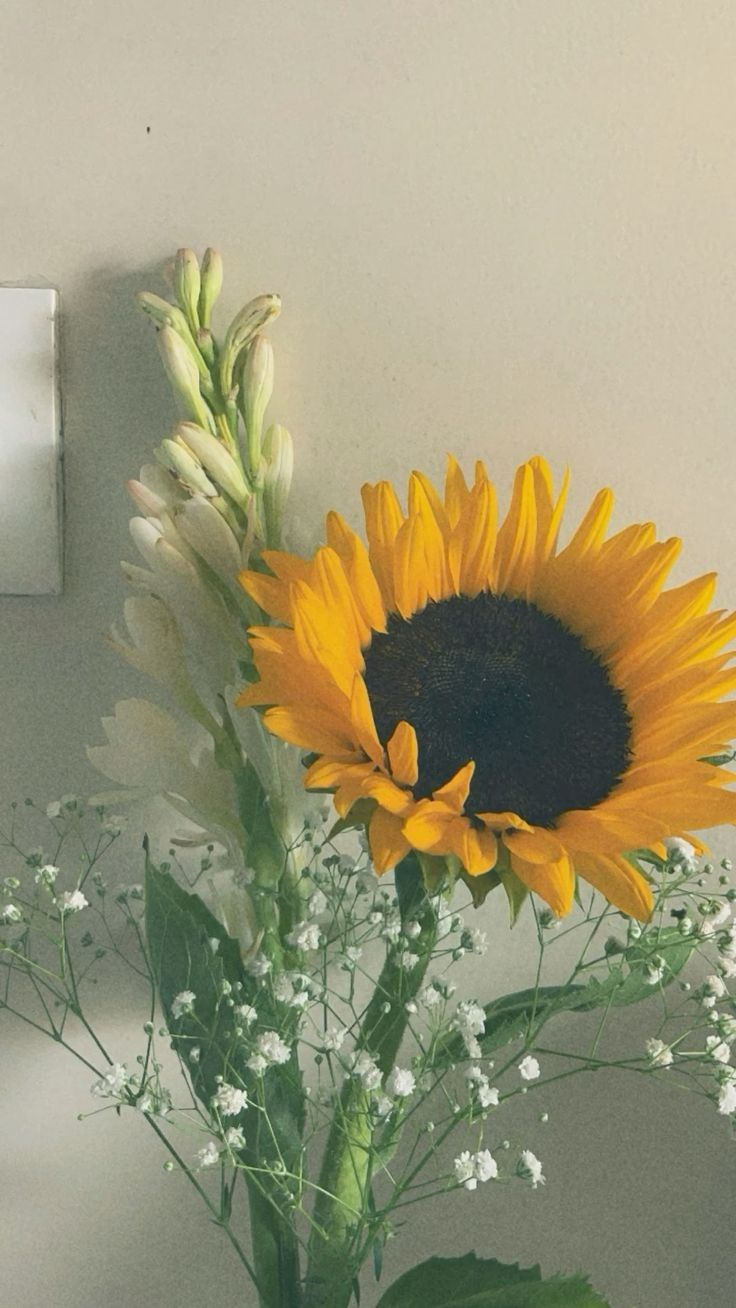

A bright yellow sunflower.
---


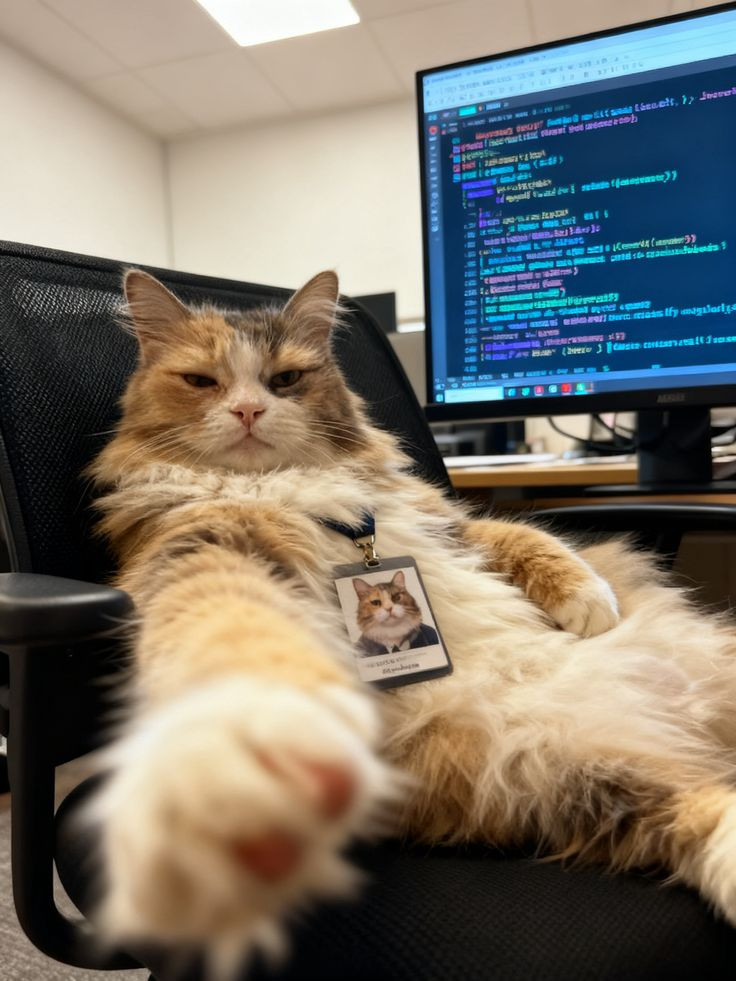

A domestic cat portrait.
---


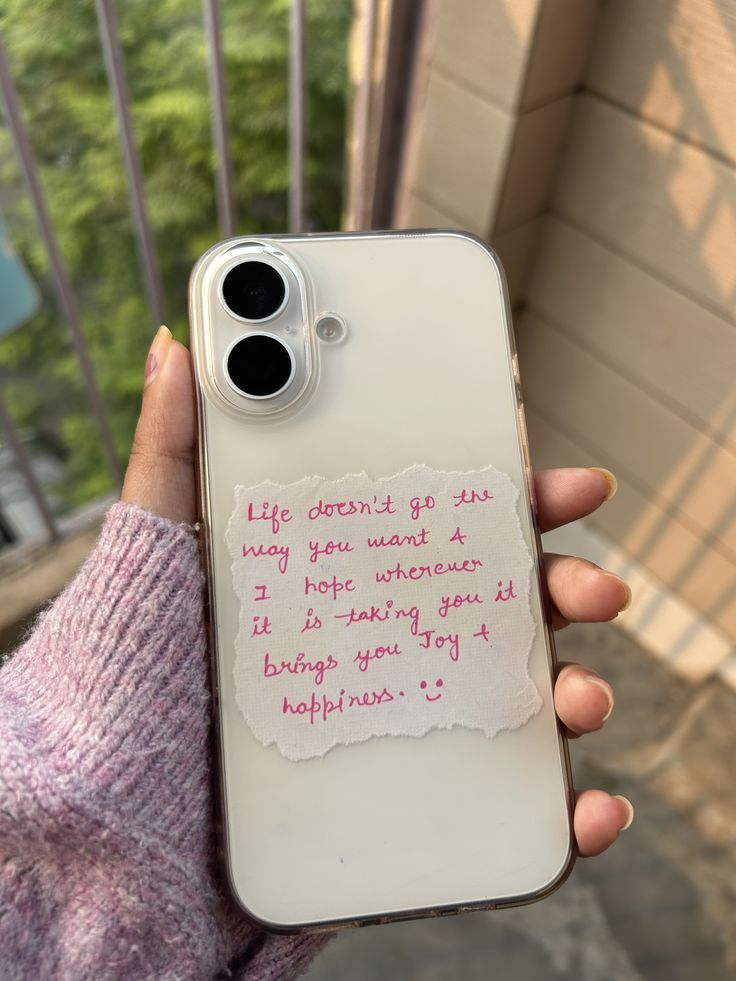

An Apple iPhone smartphone.
---


In [46]:
# Step 6 (optional) — visualize retrieved images in the notebook.
from IPython.display import Image, display

for doc, _score in retrieved:
    display(Image(filename=doc.metadata["image_path"], width=280))
    print(doc.page_content)
    print("---")


In [47]:
# Step 7 (Generate) — pass retrieved images + captions to the vision LLM and answer the question.
import base64
from pathlib import Path

from langchain_core.messages import HumanMessage


def answer_with_multimodal_rag(question: str, k: int = 2):
    """Retrieve top-k multimodal chunks, then generate an answer with Gemini vision."""
    docs = vectorstore.similarity_search(question, k=k)
    parts: list = [
        {
            "type": "text",
            "text": (
                "You are a multimodal RAG assistant. Answer ONLY from the retrieved captions and images.\n"
                "If the context is insufficient, say you do not know.\n\n"
                f"Question: {question}\n"
            ),
        }
    ]
    for i, doc in enumerate(docs, start=1):
        parts.append(
            {
                "type": "text",
                "text": (
                    f"\n--- Retrieved source {i} ({doc.metadata.get('source', '')}) ---\n"
                    f"Caption: {doc.page_content}\n"
                ),
            }
        )
        image_path = doc.metadata.get("image_path")
        if image_path and Path(image_path).is_file():
            mime, _ = mimetypes.guess_type(image_path)
            mime = mime or "image/jpeg"
            b64 = base64.standard_b64encode(Path(image_path).read_bytes()).decode()
            parts.append(
                {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{b64}"}}
            )

    response = llm.invoke([HumanMessage(content=parts)])
    return response, docs


question = "Which retrieved image shows a cat? Describe what you see."
answer, sources = answer_with_multimodal_rag(question, k=2)
print(answer.content)


The retrieved image "cat" shows a domestic cat. The cat is sitting in a chair in front of a computer monitor, with its front paws resting on the chair. It is wearing a lanyard with an ID badge that features a picture of a cat in a suit. The cat in the image has long, fluffy fur, with patches of orange, white, and brown. It has a stern expression on its face.

The retrieved image "domino" also shows a cat. This cat is white with grey tabby markings. It is also sitting in front of a computer monitor and wearing a lanyard with an ID badge. The cat in this image has a more grumpy expression.


In [48]:
# Step 7 — another example query (change this to test your own questions).
question2 = "Which image shows a smartphone or iPhone?"
answer2, _ = answer_with_multimodal_rag(question2, k=2)
print(answer2.content)


The first image shows a smartphone or iPhone.
